# HNOCA Dataset Investigation

1. The metadata field `cell_type` corresponds to a manual mapping of the original author annotations (metadata field `cell_type_original`) to the Cell Ontology. For the harmonised cell type, region, and neurotransmitter-transporter annotations, please refer to the metadata fields starting with `annot_` in the Author Categories.

2. For the HNOCA extended, you can find the harmonised cell type annotation covering all cells (including the extension datasets) in the `annot_level_2_extended` metadata field.

3. The metadata field `tissue` corresponds to the target tissue of the employed organoid differentiation protocol. For example, a cell originating from a sample generated using a cortical differentiation protocol will be annotated as `cerebral cortex`.

4. The data deposited here contains slightly fewer cells than in the data associated with the original publication. This is due to the removal of some cells with identical expression values as required by the CellxGene schema.


## Load Dataset

In [2]:
import pandas as pd
import scanpy as sc
from utils.io import read_anndata
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dask import array as da
from tqdm.dask import TqdmCallback

from utils.cellxgene import get_cxg_url
from utils.io import read_anndata


url = get_cxg_url(
    collection_id="de379e5f-52d0-498c-9801-0f850823c847",
    dataset_id="3a805b8d-c9d8-4c9b-881f-0eefa635974d"
)

dataset_name = 'He2024'
file_path = f'data/{dataset_name}.h5ad'

if not Path(file_path).exists():
    !curl {url} > {file_path}


adata = read_anndata(
    file_path,
    X='X',
    obs='obs',
    var='var',
    obsm='obsm',
)

/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Get URL for CxG collection ID "de379e5f-52d0-498c-9801-0f850823c847" and dataset ID "3a805b8d-c9d8-4c9b-881f-0eefa635974d"
URL: https://datasets.cellxgene.cziscience.com/77fef2d8-d317-4b6c-b041-174510dc1e00.h5ad
dask: False, backed: False
Read slot "X", store as "X"...
Read slot "obs", store as "obs"...
Read slot "var", store as "var"...
Read slot "obsm", store as "obsm"...


## Dataset Complexity
### Tissues

In [3]:
adata.obs["tissue"].unique()

['hindbrain', 'telencephalon', 'cerebral cortex', 'ventral part of telencephalon', 'midbrain tegmentum', ..., 'arcuate nucleus of hypothalamus', 'choroid plexus', 'cerebellum', 'midbrain tectum', 'dorsal plus ventral thalamus']
Length: 11
Categories (11, object): ['arcuate nucleus of hypothalamus', 'brain', 'cerebellum', 'cerebral cortex', ..., 'midbrain tectum', 'midbrain tegmentum', 'telencephalon', 'ventral part of telencephalon']

Sample size of the tissues:

In [4]:
sample_size = adata.obs["tissue"].value_counts()
sample_size

tissue
telencephalon                      802509
cerebral cortex                    353984
brain                              287461
midbrain tegmentum                 156397
midbrain tectum                     59980
arcuate nucleus of hypothalamus     26693
ventral part of telencephalon       23517
hindbrain                           16703
choroid plexus                      15577
cerebellum                          14285
dorsal plus ventral thalamus        10568
Name: count, dtype: int64

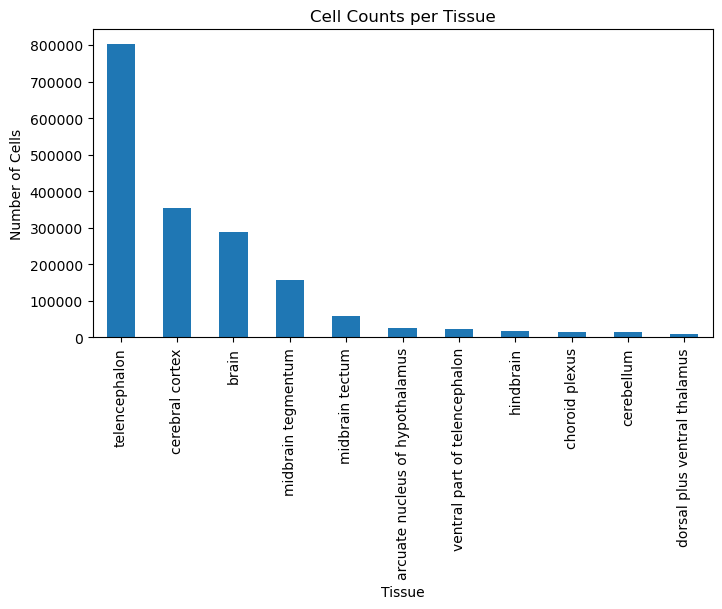

In [5]:
plt.figure(figsize=(8, 4))
sample_size.plot(kind='bar')
plt.title("Cell Counts per Tissue")
plt.xlabel("Tissue")
plt.xticks(rotation=90)
plt.ylabel("Number of Cells")
plt.show()

### Number of Cells and Genes

In [6]:
adata

AnnData object with n_obs × n_vars = 1767674 × 36720
    obs: 'assay_differentiation', 'assay_type_differentiation', 'bio_sample', 'cell_line', 'cell_type_original', 'gm', 'id', 'individual', 'state_exact', 'suspension_type', 'tech_sample', 'treatment', 'organoid_age_days', 'publication', 'doi', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'annot_level_1', 'annot_level_2', 'annot_level_3_rev2', 'annot_level_4_rev2', 'annot_region_rev2', 'annot_ntt_rev2', 'Hallmark_Glycolysis', 'tissue_type', 'sex_ontology_term_id', 'donor_id', 'assay_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type_ontology_term_id', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'mt', 'n_cells_b

### Number of Cell Types

Q: Do I use the harmonised cell types?

In [7]:
adata.obs["cell_type"].unique()

['unknown', 'radial glial cell', 'neural cell', 'cerebral cortex pyramidal neuron', 'glutamatergic neuron', ..., 'amacrine cell', 'cerebral cortex GABAergic interneuron', 'medium spiny neuron', 'ciliated cell', 'immature astrocyte']
Length: 61
Categories (61, object): ['neural crest derived neuron', 'glioblast', 'neuroblast (sensu Vertebrata)', 'neuroplacodal cell', ..., 'caudal ganglionic eminence derived cortical i..., 'medial ganglionic eminence derived GABAergic ..., 'cerebral cortex pyramidal neuron', 'unknown']

In [17]:
adata.obs["annot_level_2"].unique()


['Non-telencephalic NPC', 'Non-telencephalic Neuron', 'Ventral Telencephalic Neuron', 'Neuroepithelium', 'NC Derivatives', ..., 'Dorsal Telencephalic IP', 'CP', 'Astrocyte', 'PSC', 'Microglia']
Length: 17
Categories (17, object): ['Astrocyte', 'CP', 'Dorsal Telencephalic IP', 'Dorsal Telencephalic NPC', ..., 'OPC', 'PSC', 'Ventral Telencephalic NPC', 'Ventral Telencephalic Neuron']

In [9]:
adata.obs["cell_type"].nunique()

61

## Batch Complexity
### Number of Batches

batch = concatenation of the dataset identifier (annotation column ‘id’), the annotation of biological replicates (annotation column ‘bio_sample’) as well as technical replicates (annotation column ‘tech_sample’)

In [10]:
adata.obs["batch"].nunique()

396

### Batch Size Imbalance

In [11]:
batch_size = adata.obs["batch"].value_counts().sort_values(ascending=False)
mean = np.mean(batch_size)
std = np.std(batch_size)
min_val = batch_size.min()
max_val = batch_size.max()
print(f"Mean batch size: {mean:.2f}")
print(f"Standard deviation: {std:.2f}")
print(f"Minimum batch size: {min_val}")
print(f"Maximum batch size: {max_val}")

Mean batch size: 4463.82
Standard deviation: 3177.69
Minimum batch size: 1
Maximum batch size: 19300


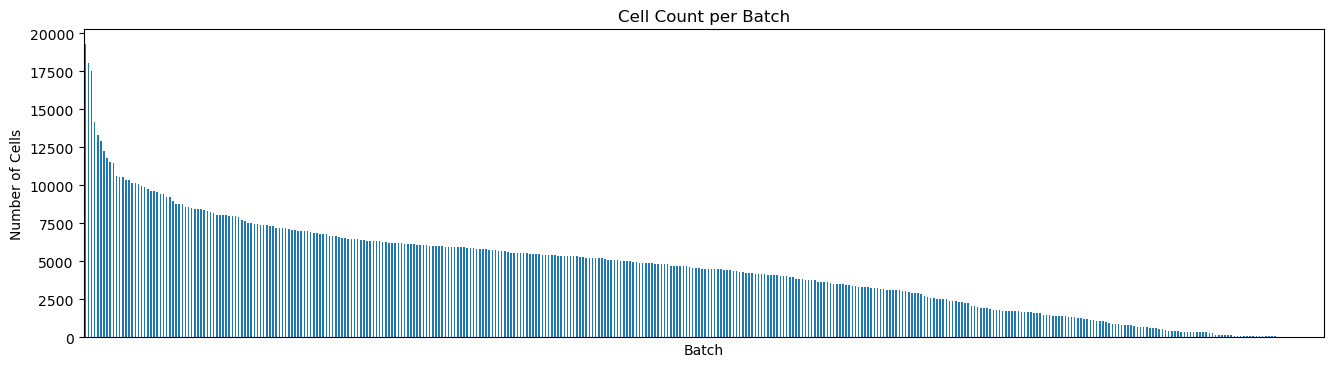

In [12]:
plt.figure(figsize=(16, 4))
batch_size.plot(kind='bar')
plt.title("Cell Count per Batch")
plt.xlabel("Batch")
plt.ylabel("Number of Cells")
plt.xticks([])
plt.show()

### Nested Batches

In [23]:
adata.obs[["batch", "individual"]].drop_duplicates().value_counts("batch")

batch
homosapiens_ventralpartoftelencephalon_2020_10x3v3_miurayuki_003_d10_1038_s41587_020_00763_w---unknown---unknown                                                                                                                                                                                                                                                                                                             1
homosapiens_None_2017_bdrhapsodywholetranscriptomeanalysis_bireyfikri_001_d10_1038_nature22330---homosapiens_None_2017_bdrhapsodywholetranscriptomeanalysis_bireyfikri_001_d10_1038_nature22330hCS---homosapiens_None_2017_bdrhapsodywholetranscriptomeanalysis_bireyfikri_001_d10_1038_nature22330hCS                                                                                                                       1
homosapiens_None_2017_bdrhapsodywholetranscriptomeanalysis_bireyfikri_001_d10_1038_nature22330---homosapiens_None_2017_bdrhapsodywholetranscriptomeanalysis_bireyfik

In [25]:
adata.obs[["batch", "individual"]].drop_duplicates().value_counts("individual")

individual
unknown                                                                                             349
homosapiens_brain_2022_10x3v2_uzquianoana_012_d10_1016_j_cell_2022_09_010GM08330 b29                  4
homosapiens_brain_2022_10x3v2_uzquianoana_013_d10_1016_j_cell_2022_09_010HUES66 b28                   4
homosapiens_telencephalon_2022_10x3v3_uzquianoana_001_d10_1016_j_cell_2022_09_010Mito 210 c1 b1       3
homosapiens_telencephalon_2022_10x3v3_uzquianoana_002_d10_1016_j_cell_2022_09_010Mito 210 c2 b6       3
homosapiens_telencephalon_2022_10x3v3_uzquianoana_003_d10_1016_j_cell_2022_09_010Mito 210 c1 b7       3
homosapiens_telencephalon_2022_10x3v3_uzquianoana_003_d10_1016_j_cell_2022_09_010PGP1 c1 b2           3
homosapiens_telencephalon_2022_10x3v3_uzquianoana_001_d10_1016_j_cell_2022_09_010PGP1 c1 b2           3
homosapiens_telencephalon_2022_10x3v3_uzquianoana_004_d10_1016_j_cell_2022_09_010Mito 210 c1 b1       3
homosapiens_telencephalon_2022_10x3v3_uzquianoana_004

batch:individual is N:1

Q: so batch is nested in individual??

### Number and Size of Samples

In [29]:
adata.obs[["bio_sample", "tech_sample"]].nunique()

bio_sample     303
tech_sample    354
dtype: int64

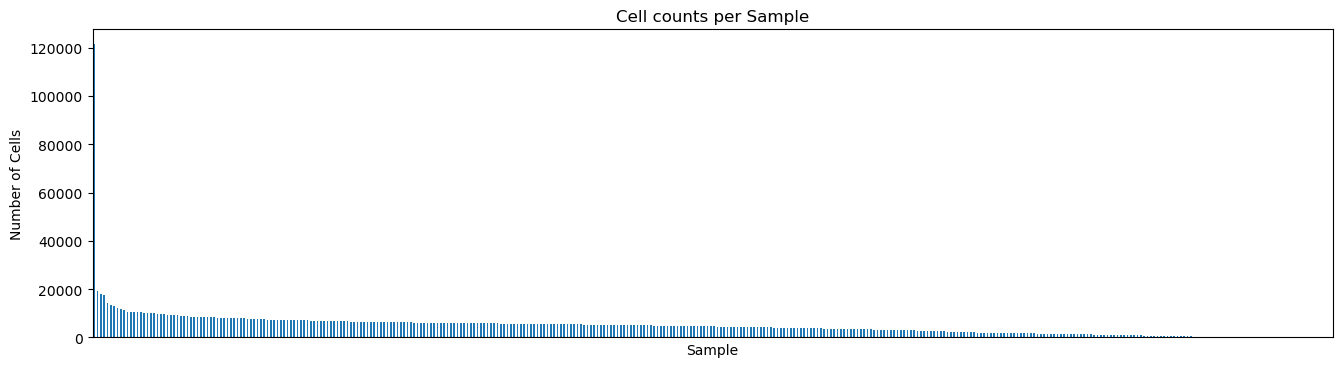

In [31]:
sample_size = adata.obs[["bio_sample", "tech_sample"]].value_counts()
plt.figure(figsize=(16, 4))
sample_size.plot(kind='bar')
plt.xlabel("Sample")
plt.ylabel("Number of Cells")
plt.title("Cell counts per Sample")
plt.xticks([])
plt.show()

### Number of Donors

In [13]:
adata.obs["individual"].nunique()

16

In [14]:
adata.obs["donor_id"].nunique()

46

### Number of Cohorts

In [15]:
adata.obs["publication"].nunique()

27

## Annotation Quality

### Resolution of Annotation

In [34]:
adata.var["feature_name"]

ensembl_id
ENSG00000000003             TSPAN6
ENSG00000000005               TNMD
ENSG00000000419               DPM1
ENSG00000000457              SCYL3
ENSG00000000460           C1orf112
                        ...       
ENSG00000288721    ENSG00000288721
ENSG00000288722               F8A1
ENSG00000288723    ENSG00000288723
ENSG00000288724    ENSG00000288724
ENSG00000288725    ENSG00000288725
Name: feature_name, Length: 36720, dtype: category
Categories (36692, object): ['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', ..., 'ZZEF1', 'ZZZ3', 'hsa-mir-1253', 'hsa-mir-423']

In [35]:
marker_genes = {
    "PSC": ["POU5F1"],
    "Neuroepithelium": ["NES", "LIN28A", "OTX2"],
    "Dorsal Telencephalic NPC": ["SOX2", "FOXG1", "EMX1"],
    "Ventral Telencephalic NPC": ["SOX2", "FOXG1", "DLX2"],
    "Non-telencephalic NPC": ["SOX2", "FOXG1", "PAX7", "HOXA2", "HOXB2", "UNC5C"],
    "Dorsal Telencephalic IP": ["EOMES"],
    "Dorsal Telencephalic Neuron": ["STMN2", "FOXG1", "EMX1", "SLC17A7"],
    "Ventral Telencephalic Neuron": ["STMN2", "FOXG1", "GAD1", "DLX5", "SLC17A6"],
    "Non-telencephalic Neuron": ["STMN2", "FOXG1", "LHX1", "LHX5", "HOXB2"],
    "Glioblast": ["TNC", "HOPX"],
    "Astrocyte": ["GFAP", "AQP4"],
    "NC Derivatives": ["SOX10"],
    "Microglia": ["AIF1"], 
    "CP": ["TTR"],
    "OPC": ["OLIG1"],
    "EC": ["CLDN5"],
    "MC": ["DCN"]
}


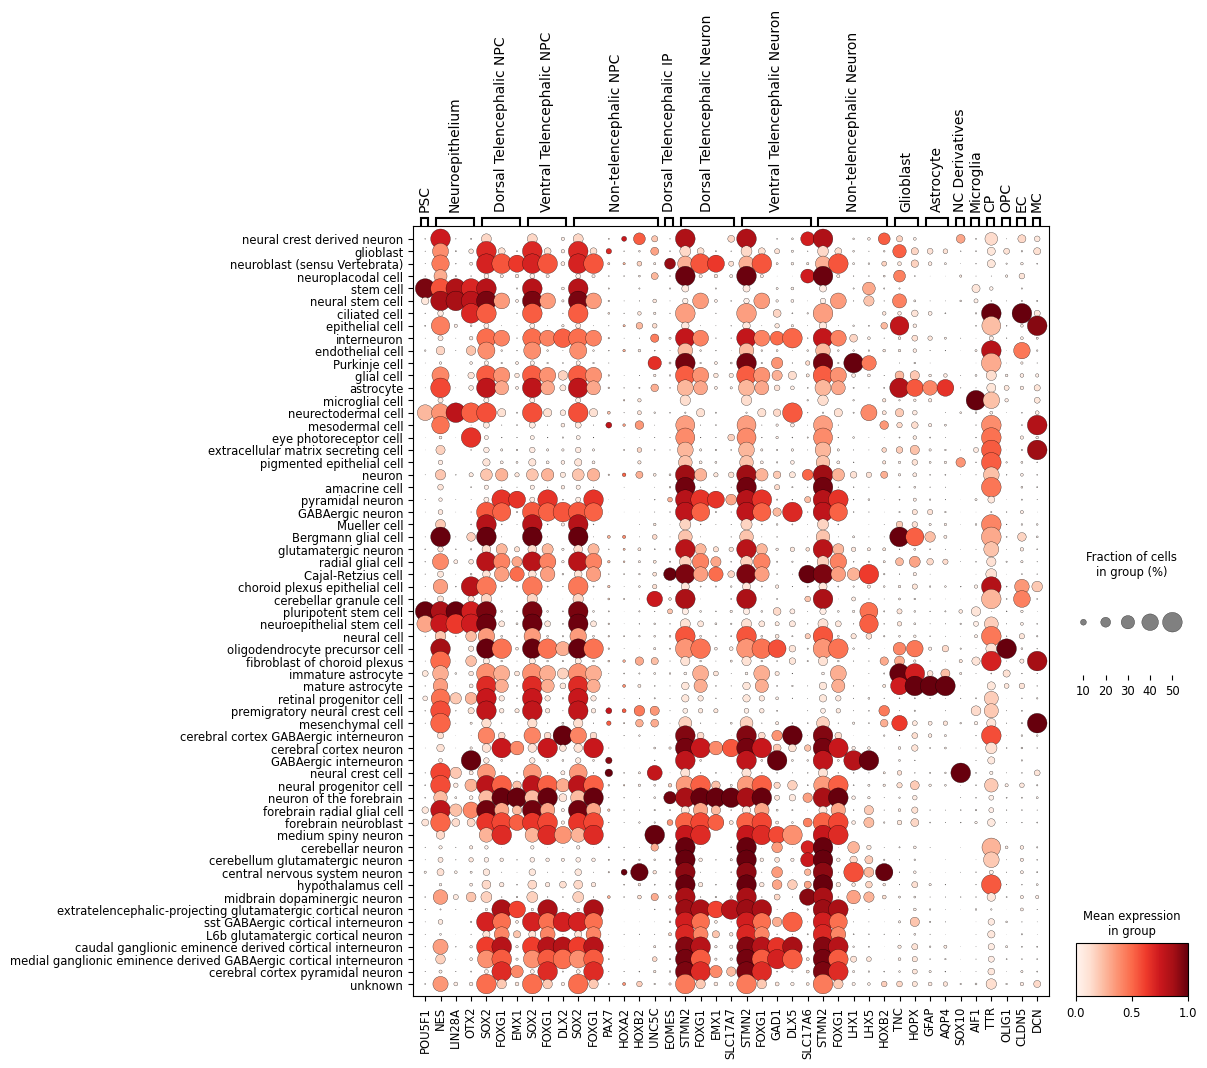

In [37]:
sc.pl.dotplot(
    adata,
    var_names=marker_genes,
    groupby='cell_type',
    gene_symbols='feature_name',
    standard_scale='var',
    dot_max=0.5,
    figsize=(10, 10)
)

### Granularity of Cell Types